In [1]:
import contextlib
import io
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_text, plot_tree

from pyforestry.sweden.site.enums import Sweden
from pyforestry.sweden.site.swedish_site import SwedishSite
from pyforestry.sweden.siteindex.sis.hagglund_lundmark_1977 import Hagglund_Lundmark_1977_SIS


class NotebookSwedishSite(SwedishSite):
    def compute_attributes(self):
        return None


# Local NFI extract, not committed. Point SIS_TEST_DATA at your own copy.
CSV_PATH = Path(os.environ["SIS_TEST_DATA"])
PARITY_THRESHOLDS = {
    "mae_max": 1.5,
    "rmse_max": 4.0,
    "abs_bias_max": 1.0,
    "pearson_min": 0.85,
}
BOOTSTRAP_SAMPLES = 400
RANDOM_STATE = 0
SUPPORT_THRESHOLD = 30


# ----------------------------
# A) Load + recode
# ----------------------------
Ytor = pd.read_csv(CSV_PATH, sep=";")

Ytor["BonitetsvisandeTradslag"] = Ytor["BonvisTslag"]
Ytor["Direktlan"] = Ytor["Dlan"]
Ytor["Jordartstextur"] = Ytor["Textur"]
Ytor["incline_percent"] = Ytor["Marklutning"]
Ytor["aspect"] = Ytor["Lutningsriktning"]
Ytor.drop(
    ["Taxar", "Dlan", "BonvisTslag", "Textur", "Lutningsriktning", "Marklutning"],
    axis=1,
    inplace=True,
    errors="ignore",
)


def enum_from_code(enum_cls, code):
    if pd.isna(code):
        return None
    code = int(code)
    if code == 0:
        return None
    for member in enum_cls:
        if member.value.code == code:
            return member
    return None


def map_soil_depth(code):
    if pd.isna(code):
        return None
    mapping = {0.0: 5, 0.05: 4, 0.1: 3, 0.45: 2, 0.8: 1}
    return mapping.get(float(code), None)


def map_climate_zone(code):
    if pd.isna(code):
        return None
    code = int(code)
    if code == 0:
        return None
    return Sweden.ClimateZone.from_code(code)


def map_ditched(before, current):
    return bool(before) or bool(current)


Ytor["soil_depth_code"] = Ytor["Jorddjup"].map(map_soil_depth)
Ytor["soil_depth"] = Ytor["soil_depth_code"].map(
    lambda c: enum_from_code(Sweden.SoilDepth, c) if c is not None else None
)
Ytor["species"] = Ytor["BonitetsvisandeTradslag"].map({10: "Pinus sylvestris", 20: "Picea abies"})
Ytor["ditched"] = Ytor.apply(
    lambda row: map_ditched(row["IsDikatForutvarande"], row["IsDikatNuvarande"]), axis=1
)
Ytor["climate_zone"] = Ytor["Lokalklimat"].apply(map_climate_zone)
Ytor["climate_code"] = Ytor["climate_zone"].apply(lambda cz: cz.value.label if cz else None)
Ytor["peat"] = Ytor["Torvtackning"].apply(lambda x: True if x == 3 else False)
Ytor["gotland"] = Ytor["Direktlan"].apply(lambda x: True if x == 31 else False)
Ytor.drop(
    ["IsDikatForutvarande", "IsDikatNuvarande", "Torvtackning"],
    axis=1,
    inplace=True,
    errors="ignore",
)
Ytor["Latitud"] = Ytor["Latitud"].apply(
    lambda x: 55.21 if x < 55.2 else (69.09 if x > 69.1 else x)
)

Ytor["soil_moisture"] = Ytor["Markfuktighet"].apply(
    lambda x: enum_from_code(Sweden.SoilMoistureEnum, x)
)
Ytor["field_layer"] = Ytor["Faltskikt"].apply(lambda x: enum_from_code(Sweden.FieldLayer, x))
Ytor["bottom_layer"] = Ytor["Bottenskikt"].apply(lambda x: enum_from_code(Sweden.BottomLayer, x))
Ytor["soil_water"] = Ytor["RorligtMarkvatten"].apply(lambda x: enum_from_code(Sweden.SoilWater, x))
Ytor["soil_texture"] = Ytor["Jordartstextur"].apply(
    lambda x: enum_from_code(Sweden.SoilTextureTill, x)
)
Ytor["county"] = Ytor["Direktlan"].apply(
    lambda x: Sweden.County.from_code(int(x)) if pd.notna(x) else None
)
Ytor["county_label"] = Ytor["county"].apply(lambda v: v.value.label if v else None)

Ytor["field_layer_label"] = Ytor["field_layer"].apply(
    lambda v: v.value.english_name if v else None
)
Ytor["soil_moisture_label"] = Ytor["soil_moisture"].apply(
    lambda v: v.value.english_description if v else None
)


# ----------------------------
# B) Compute Hagglund SIS and parity dataset
# ----------------------------
required_cols = [
    "Latitud",
    "Altitud",
    "BonitetsvisandeTradslag",
    "soil_moisture",
    "bottom_layer",
    "field_layer",
    "soil_texture",
    "climate_code",
    "soil_water",
    "soil_depth",
    "incline_percent",
    "aspect",
    "ditched",
    "peat",
    "gotland",
    "species",
    "Direktlan",
    "Longitud",
    "uf_SIS",
]


def compute_sis(row):
    with contextlib.redirect_stdout(io.StringIO()):
        try:
            return Hagglund_Lundmark_1977_SIS(
                latitude=row["Latitud"],
                altitude=row["Altitud"],
                soil_moisture=row["soil_moisture"],
                ground_layer=row["bottom_layer"],
                vegetation=row["field_layer"],
                soil_texture=row["soil_texture"],
                climate_code=row["climate_code"],
                lateral_water=row["soil_water"],
                soil_depth=row["soil_depth"],
                incline_percent=row["incline_percent"],
                aspect=row["aspect"],
                ditched=row["ditched"],
                peat=row["peat"],
                gotland=row["gotland"],
                species=row["species"],
                dlan=row["Direktlan"],
            )
        except Exception:
            return np.nan


valid_mask = Ytor[required_cols].notna().all(axis=1)
valid = Ytor.loc[valid_mask].copy()
valid["sis_hagglund_1979"] = valid.apply(compute_sis, axis=1)
valid["H1979_bin"] = np.floor(valid["sis_hagglund_1979"]).astype("Int64")
compare = valid.dropna(subset=["sis_hagglund_1979", "uf_SIS", "H1979_bin"]).copy()

# uf_SIS below zero is not a site index. The NFI stored procedures that
# produced the column (uf_SISTALL.sql, uf_SISGRAN.sql) return -1 .. -16 as
# error codes when an input is out of range, and those returns were being
# compared against a computed SIS as if they were metres -- a false +0.71 m
# bias that failed the gate on rmse and pearson. -7 accounts for every
# excluded row: the procedure rejecting Faltskikt outside 1..16, i.e. the two
# lichen types (17 Lavrik, 18 Lav) that pyforestry's FieldLayer does define.
#
# Only uf_SIS is unusable on those plots, so they are dropped from the parity
# frame alone. `compare` stays whole: the category models below predict site
# variables from sis_hagglund_1979 and never read uf_SIS (asserted in E), and
# these plots carry the only observations of the two lichen field layers --
# filtering them globally would drop both classes from the imputer.
sis_parity = compare[compare["uf_SIS"] > 0].copy()

print(f"Rows with all required columns: {len(compare):,}")
print(f"Rows usable for uf_SIS parity: {len(sis_parity):,}")


# ----------------------------
# C) Parity diagnostics
# ----------------------------
def _parity_metrics(df):
    err = df["sis_hagglund_1979"] - df["uf_SIS"]
    return {
        "n": len(df),
        "mae": float(np.abs(err).mean()),
        "rmse": float(np.sqrt(np.mean(err**2))),
        "bias": float(err.mean()),
        "pearson": float(df["sis_hagglund_1979"].corr(df["uf_SIS"], method="pearson")),
        "spearman": float(df["sis_hagglund_1979"].corr(df["uf_SIS"], method="spearman")),
    }


def _bootstrap_ci(df, metric_key, n_boot=400, random_state=0):
    rng = np.random.default_rng(random_state)
    n = len(df)
    vals = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        sample = df.iloc[idx]
        vals.append(_parity_metrics(sample)[metric_key])
    q = np.quantile(vals, [0.025, 0.975])
    return float(q[0]), float(q[1])


def _parity_by_group(df, group_col):
    rows = []
    for g, sub in df.groupby(group_col):
        m = _parity_metrics(sub)
        rows.append({group_col: g, **m})
    return pd.DataFrame(rows).sort_values("n", ascending=False)


def validate_sis_parity(df, thresholds, n_boot=400, random_state=0):
    metrics = _parity_metrics(df)
    ci_rows = []
    for k in ["mae", "bias", "rmse"]:
        lo, hi = _bootstrap_ci(df, k, n_boot=n_boot, random_state=random_state)
        ci_rows.append({"metric": k, "value": metrics[k], "ci_low": lo, "ci_high": hi})

    species_table = _parity_by_group(df, "species")
    county_table = _parity_by_group(df, "Direktlan")

    pass_gate = (
        metrics["mae"] <= thresholds["mae_max"]
        and metrics["rmse"] <= thresholds["rmse_max"]
        and abs(metrics["bias"]) <= thresholds["abs_bias_max"]
        and metrics["pearson"] >= thresholds["pearson_min"]
    )

    return {
        "global_metrics": pd.DataFrame([metrics]),
        "bootstrap_ci": pd.DataFrame(ci_rows),
        "species_table": species_table,
        "county_table": county_table,
        "pass_gate": pass_gate,
    }


def plot_bland_altman(df, title="Bland-Altman: sis_hagglund_1979 vs uf_SIS"):
    mean_val = (df["sis_hagglund_1979"] + df["uf_SIS"]) / 2.0
    diff = df["sis_hagglund_1979"] - df["uf_SIS"]
    bias = diff.mean()
    sd = diff.std(ddof=1)

    plt.figure(figsize=(10, 6))
    for sp, sub in df.groupby("species"):
        idx = sub.index
        plt.scatter(mean_val.loc[idx], diff.loc[idx], s=8, alpha=0.25, label=sp)

    plt.axhline(bias, linestyle="--", linewidth=2, color="black", label=f"Bias={bias:.3f}")
    plt.axhline(bias + 1.96 * sd, linestyle=":", linewidth=2, color="red")
    plt.axhline(bias - 1.96 * sd, linestyle=":", linewidth=2, color="red")
    plt.xlabel("Mean of two SIS implementations")
    plt.ylabel("Difference (sis_hagglund_1979 - uf_SIS)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()

Rows with all required columns: 74,539
Rows usable for uf_SIS parity: 72,224


Global parity metrics


,n,mae,rmse,bias,pearson,spearman
0,72224,0.004181,0.092385,-0.000726,0.999858,0.999804


Bootstrap 95% CI


,metric,value,ci_low,ci_high
0,mae,0.004181,0.003586,0.004816
1,bias,-0.000726,-0.001425,-0.000127
2,rmse,0.092385,0.083746,0.100135


Parity by species


,species,n,mae,rmse,bias,pearson,spearman
0,Picea abies,36996,0.000248,0.000287,0.000002,1.000000,1.00000
1,Pinus sylvestris,35228,0.008312,0.132281,-0.001490,0.999231,0.99922


Top counties by absolute bias


,Direktlan,n,mae,rmse,bias,pearson,spearman,abs_bias
3,4,699,0.013324,0.176811,0.008008,0.996580,0.996972,0.008008
18,21,801,0.005673,0.108473,-0.005418,0.999710,0.999859,0.005418
10,11,978,0.009707,0.104573,-0.004826,0.999274,0.999486,0.004826
2,3,3753,0.004367,0.082836,-0.004111,0.999441,0.999412,0.004111
24,27,3686,0.004296,0.102788,-0.004038,0.999634,0.999958,0.004038
23,26,4916,0.003507,0.086942,-0.003251,0.999826,0.999872,0.003251
12,13,11457,0.005155,0.106290,-0.002025,0.999599,0.999781,0.002025
8,9,2693,0.005132,0.112852,0.002022,0.999292,0.999403,0.002022
0,1,4390,0.006304,0.108692,0.001988,0.998911,0.999015,0.001988
15,17,1645,0.002010,0.071164,-0.001753,0.999724,0.999760,0.001753


Parity gate passed (informational): True


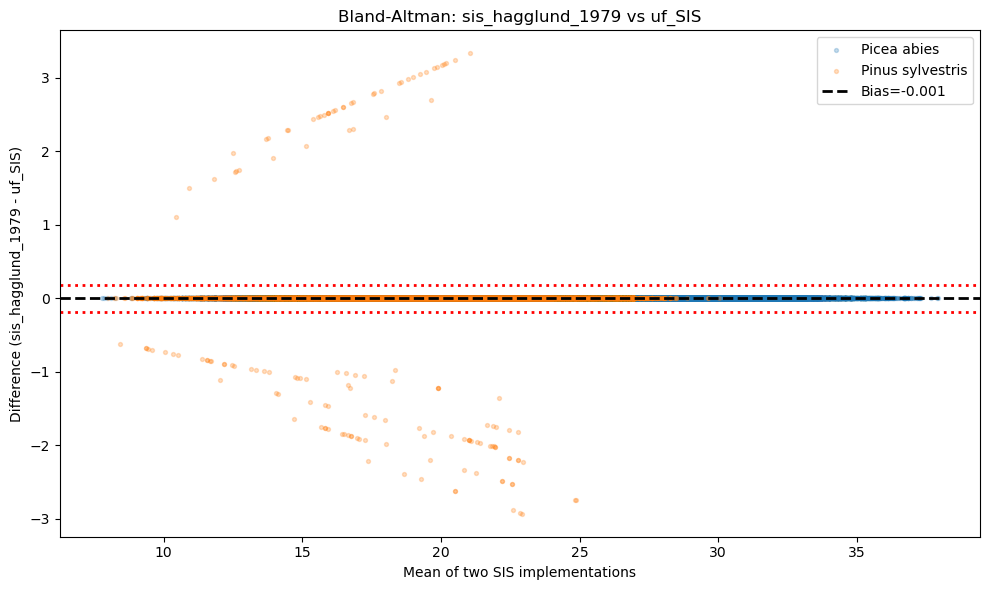

In [2]:
# ----------------------------
# D) Parity diagnostics execution
# ----------------------------
parity = validate_sis_parity(
    sis_parity,
    thresholds=PARITY_THRESHOLDS,
    n_boot=BOOTSTRAP_SAMPLES,
    random_state=RANDOM_STATE,
)

print("Global parity metrics")
display(parity["global_metrics"])

print("Bootstrap 95% CI")
display(parity["bootstrap_ci"])

print("Parity by species")
display(parity["species_table"].sort_values("species"))

print("Top counties by absolute bias")
county_bias = parity["county_table"].copy()
county_bias["abs_bias"] = county_bias["bias"].abs()
display(county_bias.sort_values("abs_bias", ascending=False).head(15))

plot_bland_altman(sis_parity)

PARITY_GATE_PASSED = parity["pass_gate"]
print("Parity gate passed (informational):", PARITY_GATE_PASSED)


In [3]:
# ----------------------------
# E) Tree-only characteristic modeling with grouped CV and fallback
# ----------------------------
MODEL_MAX_ROWS = 120_000
CV_SPLITS = 5
CV_RANDOM_STATE = 7

cat_targets = [
    "field_layer",
    "bottom_layer",
    "soil_texture",
    "soil_moisture",
    "soil_depth",
    "soil_water",
    "ditched",
]
num_targets = [
    "Latitud",
    "Longitud",
    "Altitud",
    "aspect",
    "incline_percent",
]

predictor_cols_county = ["sis_hagglund_1979", "species", "Direktlan"]
predictor_cols_global = ["sis_hagglund_1979", "species"]

for t in cat_targets + num_targets:
    assert t not in predictor_cols_county, f"Leakage: target {t} is present in predictors"
assert "uf_SIS" not in predictor_cols_county, "Leakage: uf_SIS should never be in predictors"

if len(compare) > MODEL_MAX_ROWS:
    model_df = compare.sample(n=MODEL_MAX_ROWS, random_state=RANDOM_STATE).copy()
else:
    model_df = compare.copy()

print(f"Rows used for model fitting/evaluation: {len(model_df):,}")


def to_label(value):
    if value is None or pd.isna(value):
        return "NA"
    if hasattr(value, "value"):
        inner = value.value
        for attr in (
            "label",
            "english_name",
            "english_description",
            "short_name",
            "swedish_name",
            "code",
        ):
            if hasattr(inner, attr):
                return str(getattr(inner, attr))
    return str(value)


def metric_ci(values):
    vals = np.asarray(values, dtype=float)
    mean = float(vals.mean())
    if len(vals) <= 1:
        return mean, mean, mean
    delta = 1.96 * float(vals.std(ddof=1)) / np.sqrt(len(vals))
    return mean, mean - delta, mean + delta


def make_preprocessor(feature_cols):
    cat_cols = [c for c in feature_cols if c == "species"]
    num_cols = [c for c in feature_cols if c != "species"]
    cat_pipeline = Pipeline(
        [
            ("impute", SimpleImputer(strategy="constant", fill_value="NA")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]
    )
    num_pipeline = Pipeline([("impute", SimpleImputer(strategy="median"))])
    return ColumnTransformer(
        [
            ("cat", cat_pipeline, cat_cols),
            ("num", num_pipeline, num_cols),
        ]
    )


def build_classifier_pipeline(feature_cols):
    return Pipeline(
        [
            ("pre", make_preprocessor(feature_cols)),
            (
                "clf",
                DecisionTreeClassifier(
                    random_state=RANDOM_STATE,
                    max_depth=10,
                    min_samples_leaf=20,
                    class_weight="balanced",
                ),
            ),
        ]
    )


def build_regressor_pipeline(feature_cols):
    return Pipeline(
        [
            ("pre", make_preprocessor(feature_cols)),
            (
                "reg",
                DecisionTreeRegressor(
                    random_state=RANDOM_STATE,
                    max_depth=10,
                    min_samples_leaf=20,
                ),
            ),
        ]
    )


def make_grouped_splits(df, group_col="Direktlan", n_splits=5, random_state=7):
    groups = df[group_col].astype(int).reset_index(drop=True)
    splitter = GroupShuffleSplit(
        n_splits=n_splits,
        test_size=0.2,
        random_state=random_state,
    )
    splits = []
    for train_idx, test_idx in splitter.split(df, groups=groups):
        train_groups = set(groups.iloc[train_idx].tolist())
        test_groups = set(groups.iloc[test_idx].tolist())
        assert train_groups.isdisjoint(test_groups), "Grouped split leaked county groups"
        splits.append((train_idx, test_idx))
    return splits


def reliability_table(confidence, correct, n_bins=10):
    rel = pd.DataFrame({"confidence": confidence, "correct": correct.astype(int)})
    unique_conf = rel["confidence"].nunique()
    if unique_conf < 2:
        return pd.DataFrame(
            [
                {
                    "bin": "all",
                    "mean_confidence": float(rel["confidence"].mean()),
                    "accuracy": float(rel["correct"].mean()),
                    "n": len(rel),
                }
            ]
        )
    q = min(n_bins, unique_conf)
    rel["bin"] = pd.qcut(rel["confidence"], q=q, duplicates="drop")
    out = (
        rel.groupby("bin", observed=False)
        .agg(
            mean_confidence=("confidence", "mean"),
            accuracy=("correct", "mean"),
            n=("correct", "size"),
        )
        .reset_index()
    )
    return out


def evaluate_classifier_target(X, y, splits, feature_cols):
    macro_f1 = []
    bal_acc = []
    conf_all = []
    corr_all = []

    for train_idx, test_idx in splits:
        pipe = build_classifier_pipeline(feature_cols)
        X_train = X.iloc[train_idx][feature_cols]
        X_test = X.iloc[test_idx][feature_cols]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)
        proba = pipe.predict_proba(X_test)

        macro_f1.append(f1_score(y_test, pred, average="macro", zero_division=0))
        bal_acc.append(balanced_accuracy_score(y_test, pred))

        conf_all.append(np.max(proba, axis=1))
        corr_all.append((pred == y_test.to_numpy()).astype(int))

    f1_mean, f1_lo, f1_hi = metric_ci(macro_f1)
    ba_mean, ba_lo, ba_hi = metric_ci(bal_acc)

    summary = {
        "macro_f1_mean": f1_mean,
        "macro_f1_ci_low": f1_lo,
        "macro_f1_ci_high": f1_hi,
        "balanced_accuracy_mean": ba_mean,
        "balanced_accuracy_ci_low": ba_lo,
        "balanced_accuracy_ci_high": ba_hi,
    }
    rel = reliability_table(np.concatenate(conf_all), np.concatenate(corr_all))
    return summary, rel


def evaluate_regressor_target(X, y, splits, feature_cols):
    maes = []
    rmses = []
    q90s = []

    for train_idx, test_idx in splits:
        pipe = build_regressor_pipeline(feature_cols)
        X_train = X.iloc[train_idx][feature_cols]
        X_test = X.iloc[test_idx][feature_cols]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)

        err = y_test.to_numpy() - pred
        maes.append(mean_absolute_error(y_test, pred))
        rmses.append(np.sqrt(mean_squared_error(y_test, pred)))
        q90s.append(float(np.quantile(np.abs(err), 0.9)))

    mae_mean, mae_lo, mae_hi = metric_ci(maes)
    rmse_mean, rmse_lo, rmse_hi = metric_ci(rmses)
    q90_mean, q90_lo, q90_hi = metric_ci(q90s)

    summary = {
        "mae_mean": mae_mean,
        "mae_ci_low": mae_lo,
        "mae_ci_high": mae_hi,
        "rmse_mean": rmse_mean,
        "rmse_ci_low": rmse_lo,
        "rmse_ci_high": rmse_hi,
        "abs_residual_q90_mean": q90_mean,
        "abs_residual_q90_ci_low": q90_lo,
        "abs_residual_q90_ci_high": q90_hi,
    }
    return summary


splits = make_grouped_splits(
    model_df,
    group_col="Direktlan",
    n_splits=CV_SPLITS,
    random_state=CV_RANDOM_STATE,
)

X_county = model_df[predictor_cols_county].reset_index(drop=True)
X_global = model_df[predictor_cols_global].reset_index(drop=True)

cat_models_county = {}
cat_models_global = {}
num_models_county = {}
num_models_global = {}

cat_eval_rows = []
num_eval_rows = []
cat_reliability = {}
num_q90_county = {}
num_q90_global = {}

for target in cat_targets:
    y = model_df[target].map(to_label).fillna("NA").astype(str).reset_index(drop=True)
    summary, rel = evaluate_classifier_target(X_county, y, splits, predictor_cols_county)
    cat_eval_rows.append({"target": target, **summary})
    cat_reliability[target] = rel

    model_c = build_classifier_pipeline(predictor_cols_county)
    model_c.fit(X_county[predictor_cols_county], y)
    cat_models_county[target] = model_c

    model_g = build_classifier_pipeline(predictor_cols_global)
    model_g.fit(X_global[predictor_cols_global], y)
    cat_models_global[target] = model_g

for target in num_targets:
    y = model_df[target].astype(float).reset_index(drop=True)
    summary = evaluate_regressor_target(X_county, y, splits, predictor_cols_county)
    num_eval_rows.append({"target": target, **summary})

    num_q90_county[target] = summary["abs_residual_q90_mean"]

    model_c = build_regressor_pipeline(predictor_cols_county)
    model_c.fit(X_county[predictor_cols_county], y)
    num_models_county[target] = model_c

    model_g = build_regressor_pipeline(predictor_cols_global)
    model_g.fit(X_global[predictor_cols_global], y)
    num_models_global[target] = model_g

    summary_g = evaluate_regressor_target(X_global, y, splits, predictor_cols_global)
    num_q90_global[target] = summary_g["abs_residual_q90_mean"]

cat_eval_df = pd.DataFrame(cat_eval_rows).sort_values("target")
num_eval_df = pd.DataFrame(num_eval_rows).sort_values("target")

print("Categorical target metrics (grouped CV)")
display(cat_eval_df)

print("Numeric target metrics (grouped CV)")
display(num_eval_df)

print("Reliability table example: field_layer")
display(cat_reliability["field_layer"])


def _mode_or_none(series):
    s = series.dropna()
    if s.empty:
        return None
    vc = s.value_counts()
    return vc.index[0] if not vc.empty else None


def _median_or_none(series):
    s = series.dropna()
    return float(s.median()) if not s.empty else None


def _characteristic_from_subset(subset):
    return {
        "Latitud": _median_or_none(subset["Latitud"]),
        "Longitud": _median_or_none(subset["Longitud"]),
        "Altitud": _median_or_none(subset["Altitud"]),
        "aspect": _median_or_none(subset["aspect"]),
        "incline_percent": _median_or_none(subset["incline_percent"]),
        "field_layer": _mode_or_none(subset["field_layer"]),
        "bottom_layer": _mode_or_none(subset["bottom_layer"]),
        "soil_texture": _mode_or_none(subset["soil_texture"]),
        "soil_moisture": _mode_or_none(subset["soil_moisture"]),
        "soil_depth": _mode_or_none(subset["soil_depth"]),
        "soil_water": _mode_or_none(subset["soil_water"]),
        "ditched": _mode_or_none(subset["ditched"]),
    }


from pyforestry.sweden.siteindex.sis.generated_site_category_trees import (
    predict_site_categories_county_tree,
)


global_defaults = _characteristic_from_subset(compare)
support_by_bin = compare.groupby(["species", "Direktlan", "H1979_bin"]).size().to_dict()
support_by_county = compare.groupby(["species", "Direktlan"]).size().to_dict()


def _pred_float(value):
    try:
        v = float(value)
    except (TypeError, ValueError):
        return None
    return None if np.isnan(v) else v


def _estimate_sis_for_generated_site(*, species, county_code, site):
    with contextlib.redirect_stdout(io.StringIO()):
        try:
            achieved = Hagglund_Lundmark_1977_SIS(
                latitude=site.latitude,
                altitude=site.altitude,
                soil_moisture=site.soil_moisture,
                ground_layer=site.bottom_layer,
                vegetation=site.field_layer,
                soil_texture=site.soil_texture,
                climate_code=None,
                lateral_water=site.soil_water,
                soil_depth=site.soil_depth,
                incline_percent=site.incline_percent if site.incline_percent is not None else 0.0,
                aspect=site.aspect if site.aspect is not None else 0,
                ditched=bool(site.ditched),
                peat=False,
                gotland=county_code == Sweden.County.GOTLAND.value.code,
                coast=False,
                limes_norrlandicus=bool(site.latitude > 60),
                nfi_adjustments=True,
                species=species,
                dlan=county_code,
            )
        except Exception:
            return None
    return _pred_float(achieved)


def build_site_from_inputs(
    species: str,
    sis_value: float,
    county_code: int,
    return_diagnostics: bool = True,
):
    pred_bin = int(np.floor(sis_value))
    county_code = int(county_code)

    support_n = int(support_by_bin.get((species, county_code, pred_bin), 0))
    county_support_n = int(support_by_county.get((species, county_code), 0))

    preds_cat = predict_site_categories_county_tree(
        sis_hagglund_1979=sis_value,
        species=species,
        Direktlan=county_code,
    )

    intervals = {}
    if support_n >= SUPPORT_THRESHOLD:
        feature_cols = predictor_cols_county
        num_models = num_models_county
        num_q90 = num_q90_county
        model_row = {
            "sis_hagglund_1979": sis_value,
            "species": species,
            "Direktlan": county_code,
        }
        fallback_numeric = "none"
    elif county_support_n >= SUPPORT_THRESHOLD:
        feature_cols = predictor_cols_global
        num_models = num_models_global
        num_q90 = num_q90_global
        model_row = {
            "sis_hagglund_1979": sis_value,
            "species": species,
        }
        fallback_numeric = "global_tree"
    else:
        model_row = None
        fallback_numeric = "global_defaults"

    if model_row is not None:
        example_input = pd.DataFrame([model_row])
        preds_num = {
            t: _pred_float(num_models[t].predict(example_input[feature_cols])[0])
            for t in num_targets
        }
        for t in num_targets:
            center = preds_num[t]
            q = float(num_q90.get(t, np.nan))
            if center is None or np.isnan(q):
                intervals[t] = (None, None)
            else:
                intervals[t] = (center - q, center + q)
    else:
        preds_num = {
            "Latitud": global_defaults["Latitud"],
            "Longitud": global_defaults["Longitud"],
            "Altitud": global_defaults["Altitud"],
            "aspect": global_defaults["aspect"],
            "incline_percent": global_defaults["incline_percent"],
        }

    latitude = preds_num["Latitud"] or global_defaults["Latitud"]
    longitude = preds_num["Longitud"] or global_defaults["Longitud"]
    altitude = preds_num["Altitud"] or global_defaults["Altitud"]

    if latitude is None or longitude is None:
        raise ValueError("Latitude/Longitude missing for site construction.")

    site = NotebookSwedishSite(
        latitude=latitude,
        longitude=longitude,
        altitude=altitude,
        field_layer=preds_cat["field_layer"] or global_defaults["field_layer"],
        bottom_layer=preds_cat["bottom_layer"] or global_defaults["bottom_layer"],
        soil_texture=preds_cat["soil_texture"] or global_defaults["soil_texture"],
        soil_moisture=preds_cat["soil_moisture"] or global_defaults["soil_moisture"],
        soil_depth=preds_cat["soil_depth"] or global_defaults["soil_depth"],
        soil_water=preds_cat["soil_water"] or global_defaults["soil_water"],
        aspect=(
            preds_num["aspect"] if preds_num["aspect"] is not None else global_defaults["aspect"]
        ),
        incline_percent=(
            preds_num["incline_percent"]
            if preds_num["incline_percent"] is not None
            else global_defaults["incline_percent"]
        ),
        ditched=(
            preds_cat["ditched"]
            if preds_cat["ditched"] is not None
            else global_defaults["ditched"]
        ),
    )

    achieved_sis = _estimate_sis_for_generated_site(
        species=species,
        county_code=county_code,
        site=site,
    )
    requested_sis = float(sis_value)
    sis_abs_error = None if achieved_sis is None else abs(achieved_sis - requested_sis)
    sis_rel_error_pct = (
        None
        if achieved_sis is None or requested_sis == 0
        else 100.0 * sis_abs_error / abs(requested_sis)
    )

    diagnostics = {
        "support_n": support_n,
        "county_support_n": county_support_n,
        "fallback_numeric": fallback_numeric,
        "warning_flag": fallback_numeric != "none",
        "prediction_intervals_q90": intervals,
        "requested_sis": requested_sis,
        "achieved_sis": achieved_sis,
        "sis_abs_error": sis_abs_error,
        "sis_rel_error_pct": sis_rel_error_pct,
        "within_0_5m": sis_abs_error is not None and sis_abs_error <= 0.5,
        "within_1_0m": sis_abs_error is not None and sis_abs_error <= 1.0,
    }

    if return_diagnostics:
        return pred_bin, site, diagnostics
    return pred_bin, site



Rows used for model fitting/evaluation: 74,539


Categorical target metrics (grouped CV)


,target,macro_f1_mean,macro_f1_ci_low,macro_f1_ci_high,balanced_accuracy_mean,balanced_accuracy_ci_low,balanced_accuracy_ci_high
1,bottom_layer,0.288649,0.265975,0.311324,0.356812,0.343259,0.370366
6,ditched,0.480131,0.454832,0.505430,0.579437,0.555722,0.603151
0,field_layer,0.110377,0.097526,0.123228,0.186866,0.163934,0.209799
4,soil_depth,0.363876,0.304148,0.423604,0.503128,0.409656,0.596600
3,soil_moisture,0.243880,0.229451,0.258309,0.331064,0.304737,0.357391
2,soil_texture,0.143203,0.120694,0.165712,0.269184,0.230341,0.308028
5,soil_water,0.427749,0.413845,0.441654,0.451894,0.424397,0.479391


Numeric target metrics (grouped CV)


,target,mae_mean,mae_ci_low,mae_ci_high,rmse_mean,rmse_ci_low,rmse_ci_high,abs_residual_q90_mean,abs_residual_q90_ci_low,abs_residual_q90_ci_high
2,Altitud,115.735806,100.407912,131.063699,148.614671,127.651026,169.578316,245.269151,210.519411,280.018891
0,Latitud,0.835524,0.657754,1.013294,0.945326,0.734177,1.156474,1.435050,1.070118,1.799982
1,Longitud,1.839778,1.365673,2.313882,2.331130,1.795325,2.866936,3.906044,3.004382,4.807706
3,aspect,91.383007,90.105060,92.660955,106.323964,104.494681,108.153246,164.442004,162.546786,166.337222
4,incline_percent,6.445568,6.201246,6.689891,9.230626,8.662400,9.798852,13.699040,12.843650,14.554429


Reliability table example: field_layer


,bin,mean_confidence,accuracy,n
0,"(0.145, 0.224]",0.205101,0.122644,7746
1,"(0.224, 0.273]",0.254506,0.259932,7375
2,"(0.273, 0.302]",0.283315,0.133603,7163
3,"(0.302, 0.326]",0.311299,0.130876,7488
4,"(0.326, 0.369]",0.344002,0.190211,7376
5,"(0.369, 0.402]",0.385341,0.204353,7306
6,"(0.402, 0.465]",0.436334,0.151775,7465
7,"(0.465, 0.535]",0.496552,0.125736,7476
8,"(0.535, 0.725]",0.611001,0.177862,7354
9,"(0.725, 1.0]",0.847533,0.136494,7319


In [4]:
# ----------------------------
# F) Example usage: generated categorical site predictions + SIS closeness
# ----------------------------
examples = [
    {"species": "Picea abies", "sis_value": 26.4, "county_code": 14},
    {"species": "Pinus sylvestris", "sis_value": 22.8, "county_code": 12},
]

for ex in examples:
    pred_bin, site, diagnostics = build_site_from_inputs(
        species=ex["species"],
        sis_value=ex["sis_value"],
        county_code=ex["county_code"],
    )

    print(
        f"species={ex['species']}, county={ex['county_code']}, requested_SIS={ex['sis_value']:.2f}"
    )
    print(f"Predicted H1979_bin: {pred_bin}")
    print(site)

    closeness = pd.DataFrame(
        [
            {
                "requested_sis": diagnostics["requested_sis"],
                "achieved_sis": diagnostics["achieved_sis"],
                "sis_abs_error": diagnostics["sis_abs_error"],
                "sis_rel_error_pct": diagnostics["sis_rel_error_pct"],
                "within_0_5m": diagnostics["within_0_5m"],
                "within_1_0m": diagnostics["within_1_0m"],
                "fallback_numeric": diagnostics["fallback_numeric"],
                "support_n": diagnostics["support_n"],
                "county_support_n": diagnostics["county_support_n"],
            }
        ]
    )
    display(closeness)



species=Picea abies, county=14, requested_SIS=26.40
Predicted H1979_bin: 26
NotebookSwedishSite(latitude=59.79718309859154, longitude=14.572477064220184, altitude=232.89119170984455, field_layer=<SwedenFieldLayer.BROADLEAVED_GRASS: Vegetation(code=8, swedish_name='Bredbl. gräs', english_name='Broadleaved grass', index=2.5)>, bottom_layer=<SwedenBottomLayer.SWAMP_MOSS: BottomLayerType(code=5, english_name='Swamp moss type', swedish_name='Sumpmosstyp')>, soil_texture=<SwedenSoilTextureTill.SILTY_SAND: SoilTextureCategory(code=5, swedish_name='Finmoig morän', english_name='Silty-sandy till', short_name='Fine sand')>, soil_moisture=<SwedenSoilMoisture.MESIC_MOIST: SoilMoistureData(code=3, swedish_description='frisk-fuktig', english_description='Mesic-moist (subsoil water depth <1 m)')>, soil_depth=<SwedenSoilDepth.DEEP: SoilDepthCat(code=1, swedish_description='Mäktigt >70 cm. Inga synliga hällar', english_description='Deep >70cm. No visible stone outcrops.')>, soil_water=<SwedenSoilWater.

,requested_sis,achieved_sis,sis_abs_error,sis_rel_error_pct,within_0_5m,within_1_0m,fallback_numeric,support_n,county_support_n
0,26.4,26.200812,0.199188,0.7545,True,True,none,84,425


species=Pinus sylvestris, county=12, requested_SIS=22.80
Predicted H1979_bin: 22
NotebookSwedishSite(latitude=60.76747352496223, longitude=14.360975609756101, altitude=349.6088379705401, field_layer=<SwedenFieldLayer.BILBERRY: Vegetation(code=13, swedish_name='Blåbär', english_name='European blueberry, bilberry', index=0)>, bottom_layer=<SwedenBottomLayer.FRESH_MOSS: BottomLayerType(code=6, english_name='Fresh moss type', swedish_name='Friskmosstyp')>, soil_texture=<SwedenSoilTextureTill.SILTY_SAND: SoilTextureCategory(code=5, swedish_name='Finmoig morän', english_name='Silty-sandy till', short_name='Fine sand')>, soil_moisture=<SwedenSoilMoisture.MESIC: SoilMoistureData(code=2, swedish_description='frisk', english_description='Mesic (subsoil water depth = 1-2 m)')>, soil_depth=<SwedenSoilDepth.DEEP: SoilDepthCat(code=1, swedish_description='Mäktigt >70 cm. Inga synliga hällar', english_description='Deep >70cm. No visible stone outcrops.')>, soil_water=<SwedenSoilWater.SELDOM_NEVER: So

,requested_sis,achieved_sis,sis_abs_error,sis_rel_error_pct,within_0_5m,within_1_0m,fallback_numeric,support_n,county_support_n
0,22.8,22.561451,0.238549,1.04627,True,True,none,657,6140


|--- sis_hagglund_1979 <= 20.30
|   |--- species_Picea abies <= 0.50
|   |   |--- sis_hagglund_1979 <= 16.38
|   |   |   |--- sis_hagglund_1979 <= 12.69
|   |   |   |   |--- Direktlan <= 4.00
|   |   |   |   |   |--- sis_hagglund_1979 <= 12.51
|   |   |   |   |   |   |--- sis_hagglund_1979 <= 11.97
|   |   |   |   |   |   |   |--- sis_hagglund_1979 <= 10.05
|   |   |   |   |   |   |   |   |--- class: Horsetail, Equisetum ssp.
|   |   |   |   |   |   |   |--- sis_hagglund_1979 >  10.05
|   |   |   |   |   |   |   |   |--- sis_hagglund_1979 <= 11.32
|   |   |   |   |   |   |   |   |   |--- sis_hagglund_1979 <= 10.92
|   |   |   |   |   |   |   |   |   |   |--- class: Sedge, low
|   |   |   |   |   |   |   |   |   |--- sis_hagglund_1979 >  10.92
|   |   |   |   |   |   |   |   |   |   |--- class: Poor shrub
|   |   |   |   |   |   |   |   |--- sis_hagglund_1979 >  11.32
|   |   |   |   |   |   |   |   |   |--- Direktlan <= 1.50
|   |   |   |   |   |   |   |   |   |   |--- class: Horsetail

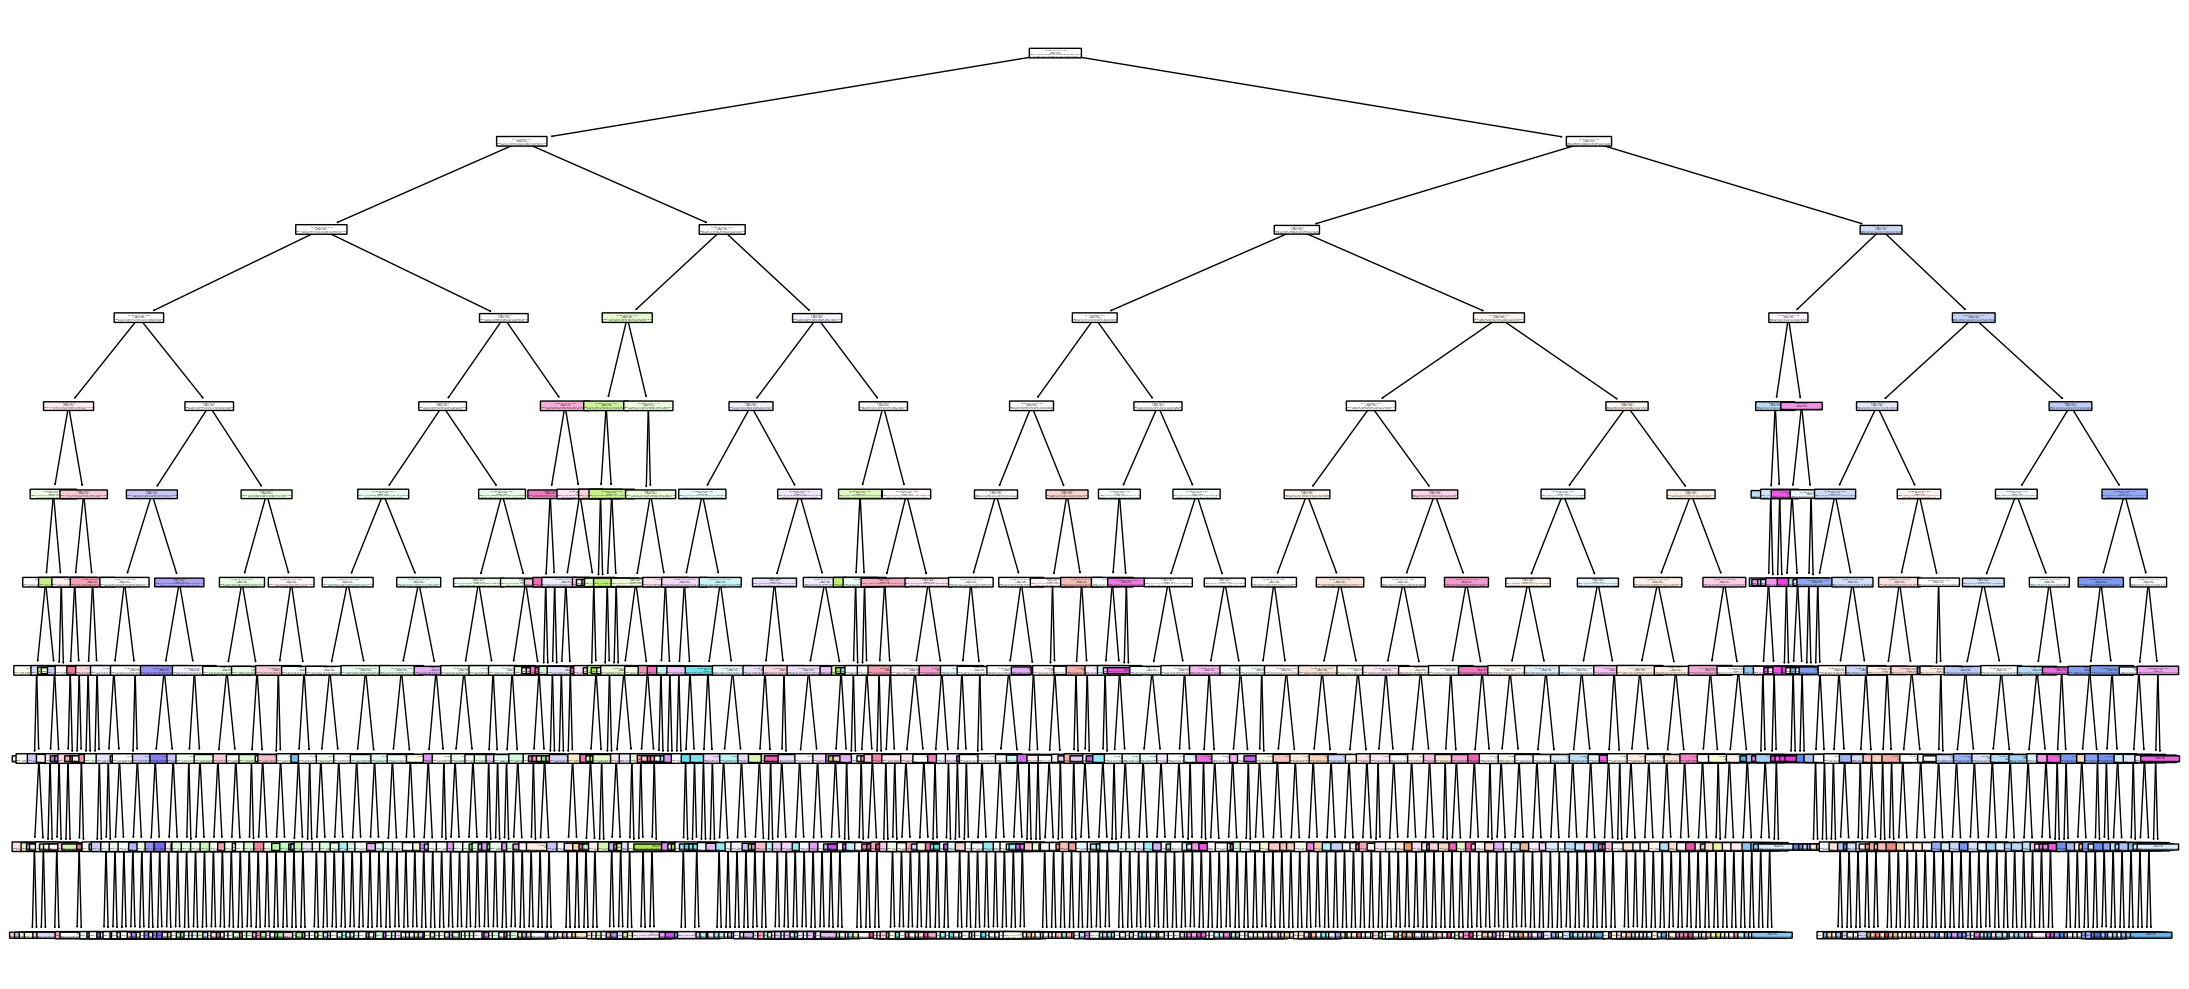

In [5]:
# ----------------------------
# G) Export representative tree rules
# ----------------------------
def transformed_feature_names(pre, feature_cols):
    cat_cols = [c for c in feature_cols if c == "species"]
    num_cols = [c for c in feature_cols if c != "species"]
    cat_pipe = pre.named_transformers_["cat"]
    ohe = cat_pipe.named_steps["onehot"]
    return list(ohe.get_feature_names_out(cat_cols)) + num_cols


representative_target = "field_layer"
representative_pipe = cat_models_county[representative_target]
representative_tree = representative_pipe.named_steps["clf"]
representative_pre = representative_pipe.named_steps["pre"]
representative_feature_names = transformed_feature_names(
    representative_pre,
    predictor_cols_county,
)

rules = export_text(
    representative_tree,
    feature_names=representative_feature_names,
)
print(rules)

plt.figure(figsize=(22, 10))
plot_tree(
    representative_tree,
    feature_names=representative_feature_names,
    filled=True,
    rounded=True,
)
plt.tight_layout()

Fallback coverage (using SUPPORT_THRESHOLD logic)


,fallback,n,share_pct
0,none,68407,94.715053
1,global_tree,3776,5.228179
2,global_defaults,41,0.056768


Fallback split by species


,species,fallback,n,share_pct
2,Picea abies,none,34842,94.177749
1,Picea abies,global_tree,2130,5.757379
0,Picea abies,global_defaults,24,0.064872
5,Pinus sylvestris,none,33565,95.279323
4,Pinus sylvestris,global_tree,1646,4.672420
3,Pinus sylvestris,global_defaults,17,0.048257


Worst species/county residual segments (n >= 250)


,species,Direktlan,n,mae,bias,rmse,abs_bias
52,Pinus sylvestris,27,531,0.028350,-0.028100,0.270813,0.028100
31,Pinus sylvestris,4,449,0.020613,0.012469,0.220609,0.012469
51,Pinus sylvestris,26,1648,0.009961,-0.009718,0.150160,0.009718
34,Pinus sylvestris,7,339,0.023987,0.007048,0.230470,0.007048
30,Pinus sylvestris,3,2390,0.006716,-0.006460,0.103803,0.006460
38,Pinus sylvestris,11,832,0.011364,-0.005670,0.113377,0.005670
40,Pinus sylvestris,13,4204,0.013625,-0.005516,0.175467,0.005516
43,Pinus sylvestris,17,728,0.004213,-0.003956,0.106973,0.003956
47,Pinus sylvestris,22,610,0.003860,-0.003587,0.089231,0.003587
36,Pinus sylvestris,9,1727,0.007859,0.003163,0.140923,0.003163


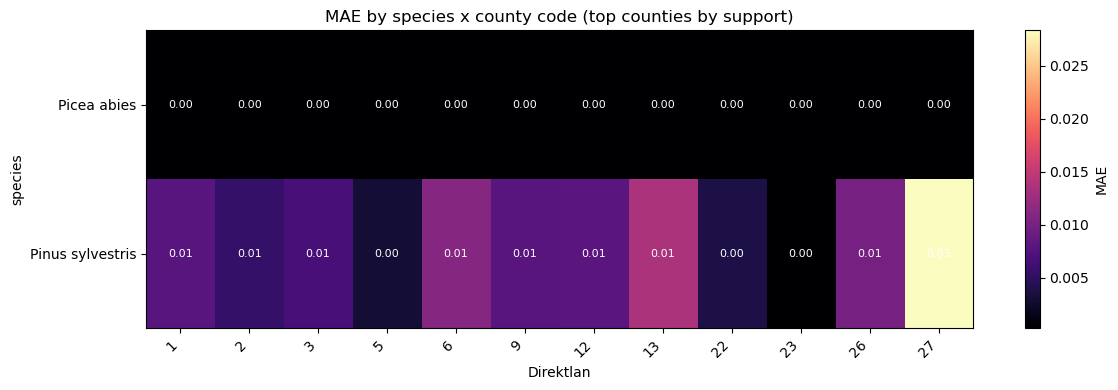

In [6]:
# ----------------------------
# F) Fallback coverage and residual heatmap diagnostics
# ----------------------------
support_bin = (
    compare.groupby(["species", "Direktlan", "H1979_bin"], observed=False)
    .size()
    .rename("support_n")
    .reset_index()
)
support_county = (
    compare.groupby(["species", "Direktlan"], observed=False)
    .size()
    .rename("county_support_n")
    .reset_index()
)

diagnostics_df = (
    sis_parity[["species", "Direktlan", "H1979_bin", "sis_hagglund_1979", "uf_SIS"]]
    .merge(support_bin, on=["species", "Direktlan", "H1979_bin"], how="left")
    .merge(support_county, on=["species", "Direktlan"], how="left")
)

diagnostics_df["fallback"] = np.where(
    diagnostics_df["support_n"] >= SUPPORT_THRESHOLD,
    "none",
    np.where(
        diagnostics_df["county_support_n"] >= SUPPORT_THRESHOLD,
        "global_tree",
        "global_defaults",
    ),
)
diagnostics_df["error"] = diagnostics_df["sis_hagglund_1979"] - diagnostics_df["uf_SIS"]
diagnostics_df["abs_error"] = diagnostics_df["error"].abs()

fallback_summary = diagnostics_df["fallback"].value_counts().rename_axis("fallback").to_frame("n")
fallback_summary["share_pct"] = 100.0 * fallback_summary["n"] / len(diagnostics_df)
print("Fallback coverage (using SUPPORT_THRESHOLD logic)")
display(fallback_summary.reset_index().sort_values("n", ascending=False))

fallback_by_species = (
    diagnostics_df.groupby(["species", "fallback"], observed=False)
    .size()
    .rename("n")
    .reset_index()
)
fallback_by_species["share_pct"] = 100.0 * fallback_by_species["n"] / fallback_by_species.groupby("species")["n"].transform("sum")
print("Fallback split by species")
display(fallback_by_species.sort_values(["species", "n"], ascending=[True, False]))

min_n = 250
segment_residuals = (
    diagnostics_df.groupby(["species", "Direktlan"], observed=False)
    .agg(
        n=("error", "size"),
        mae=("abs_error", "mean"),
        bias=("error", "mean"),
        rmse=("error", lambda s: float(np.sqrt(np.mean(np.square(s))))),
    )
    .reset_index()
)
worst_segments = (
    segment_residuals.loc[segment_residuals["n"] >= min_n]
    .assign(abs_bias=lambda df: df["bias"].abs())
    .sort_values(["abs_bias", "mae"], ascending=False)
    .head(20)
)
print(f"Worst species/county residual segments (n >= {min_n})")
display(worst_segments)

top_counties = diagnostics_df["Direktlan"].value_counts().head(12).index.tolist()
heat = (
    diagnostics_df.loc[diagnostics_df["Direktlan"].isin(top_counties)]
    .groupby(["species", "Direktlan"], observed=False)["abs_error"]
    .mean()
    .unstack("Direktlan")
    .sort_index()
)

plt.figure(figsize=(12, 4))
im = plt.imshow(heat.to_numpy(), aspect="auto", cmap="magma")
plt.yticks(range(len(heat.index)), heat.index)
plt.xticks(range(len(heat.columns)), [str(c) for c in heat.columns], rotation=45, ha="right")
plt.title("MAE by species x county code (top counties by support)")
plt.xlabel("Direktlan")
plt.ylabel("species")
cbar = plt.colorbar(im)
cbar.set_label("MAE")

for r in range(heat.shape[0]):
    for c in range(heat.shape[1]):
        value = heat.iat[r, c]
        if pd.notna(value):
            plt.text(c, r, f"{value:.2f}", ha="center", va="center", fontsize=8, color="white")

plt.tight_layout()
plt.show()


In [7]:
# ----------------------------
# H) Export all categorical county trees to the package data asset
# ----------------------------
# The package module
# src/pyforestry/sweden/siteindex/sis/generated_site_category_trees.py is
# hand-maintained: it is a documented loader that reads its fitted tables from
# the sibling site_category_trees.json through importlib.resources. This cell
# regenerates that JSON only. Writing the .py -- as this cell used to -- would
# replace the loader with inline literals and orphan the data asset.
import importlib
import json
from pathlib import Path


def _extract_classifier_payload(pipe, *, feature_cols):
    pre = pipe.named_steps["pre"]
    clf = pipe.named_steps["clf"]

    cat_pipe = pre.named_transformers_["cat"]
    cat_imputer = cat_pipe.named_steps["impute"]
    ohe = cat_pipe.named_steps["onehot"]

    species_categories = [str(v) for v in ohe.categories_[0].tolist()]
    species_fill = str(cat_imputer.fill_value)

    num_pipe = pre.named_transformers_["num"]
    num_imputer = num_pipe.named_steps["impute"]
    num_cols = [c for c in feature_cols if c != "species"]
    numeric_defaults = {
        col: float(stat) for col, stat in zip(num_cols, num_imputer.statistics_)
    }

    feature_names = list(ohe.get_feature_names_out(["species"])) + num_cols
    tree = clf.tree_

    payload = {
        "feature_names": feature_names,
        "tree_feature": tree.feature.tolist(),
        "tree_threshold": [float(x) for x in tree.threshold.tolist()],
        "tree_left": tree.children_left.tolist(),
        "tree_right": tree.children_right.tolist(),
        "tree_values": tree.value[:, 0, :].tolist(),
        "class_labels": [str(c) for c in clf.classes_.tolist()],
    }
    shared_meta = {
        "species_categories": species_categories,
        "species_fill_value": species_fill,
        "numeric_defaults": numeric_defaults,
    }
    return payload, shared_meta


def build_site_category_tables(cat_models, *, feature_cols):
    if not cat_models:
        raise ValueError("cat_models is empty.")

    target_models = {}
    shared_meta = None

    for target in cat_targets:
        payload, meta = _extract_classifier_payload(
            cat_models[target],
            feature_cols=feature_cols,
        )
        target_models[target] = payload

        if shared_meta is None:
            shared_meta = meta
        elif meta != shared_meta:
            raise ValueError(
                "All classifier pipelines must share the same preprocessing metadata."
            )

    return {
        "CAT_TARGETS": list(cat_targets),
        "SPECIES_CATEGORIES": shared_meta["species_categories"],
        "SPECIES_FILL_VALUE": shared_meta["species_fill_value"],
        "NUMERIC_DEFAULTS": shared_meta["numeric_defaults"],
        "TARGET_MODELS": target_models,
    }


def _resolve_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    return start


tables = build_site_category_tables(
    cat_models_county,
    feature_cols=predictor_cols_county,
)

repo_root = _resolve_repo_root(Path.cwd().resolve())
export_path = repo_root / "src/pyforestry/sweden/siteindex/sis/site_category_trees.json"
export_path.parent.mkdir(parents=True, exist_ok=True)
# Compact separators, matching how the asset is already stored.
export_path.write_text(
    json.dumps(tables, separators=(",", ":")),
    encoding="utf-8",
)

# Relative: an absolute path here would write this machine's home directory into
# outputs that CI cannot regenerate away.
rel_export = export_path.relative_to(repo_root).as_posix()
node_counts = {t: len(m["tree_feature"]) for t, m in tables["TARGET_MODELS"].items()}
class_counts = {t: len(m["class_labels"]) for t, m in tables["TARGET_MODELS"].items()}
print(f"Wrote fitted decision-tree tables: {rel_export}")
print(f"Targets: {', '.join(tables['CAT_TARGETS'])}")
print(f"Species categories: {tables['SPECIES_CATEGORIES']}")
print(f"Numeric defaults: {tables['NUMERIC_DEFAULTS']}")
print(f"Nodes per target: {node_counts}")
print(f"Classes per target: {class_counts}")

# Sanity check: the packaged function, reloaded from the tables just written,
# must reproduce the in-memory sklearn pipelines.
from pyforestry.sweden.siteindex.sis import generated_site_category_trees as generated

importlib.reload(generated)
generated_fn = generated.predict_site_categories_county_tree

sample_n = min(500, len(compare))
sample = compare.sample(n=sample_n, random_state=RANDOM_STATE).copy()

pipeline_preds = {
    target: cat_models_county[target].predict(sample[predictor_cols_county])
    for target in cat_targets
}
generated_preds = [
    generated_fn(
        sis_hagglund_1979=row["sis_hagglund_1979"],
        species=row["species"],
        Direktlan=row["Direktlan"],
    )
    for _, row in sample.iterrows()
]

agreement_rows = []
for target in cat_targets:
    generated_labels = np.asarray(
        [to_label(pred[target]) for pred in generated_preds], dtype=object
    )
    agreement = float(np.mean(generated_labels == pipeline_preds[target]))
    agreement_rows.append({"target": target, "agreement": agreement})

agreement_df = pd.DataFrame(agreement_rows).sort_values("target")
print(f"Agreement vs sklearn pipeline on sample (n={sample_n})")
display(agreement_df)
print(f"Minimum per-target agreement: {agreement_df['agreement'].min():.3%}")


Wrote fitted decision-tree tables: src/pyforestry/sweden/siteindex/sis/site_category_trees.json
Targets: field_layer, bottom_layer, soil_texture, soil_moisture, soil_depth, soil_water, ditched
Species categories: ['Picea abies', 'Pinus sylvestris']
Numeric defaults: {'sis_hagglund_1979': 21.079271262488223, 'Direktlan': 12.0}
Nodes per target: {'field_layer': 1135, 'bottom_layer': 925, 'soil_texture': 853, 'soil_moisture': 909, 'soil_depth': 917, 'soil_water': 1157, 'ditched': 921}
Classes per target: {'field_layer': 18, 'bottom_layer': 6, 'soil_texture': 9, 'soil_moisture': 5, 'soil_depth': 5, 'soil_water': 3, 'ditched': 2}
Agreement vs sklearn pipeline on sample (n=500)


,target,agreement
1,bottom_layer,1.0
6,ditched,1.0
0,field_layer,1.0
4,soil_depth,1.0
3,soil_moisture,1.0
2,soil_texture,1.0
5,soil_water,1.0


Minimum per-target agreement: 100.000%
